In [1]:
import pandas as pd

df = pd.read_csv("titanic_dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.shape

(891, 12)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Q1. Create a Bar Chart to show the survival rate of passengers from each Embarked port.
## X-axis: Embarked
## Y-axis: Average of Survived
## Add proper title and labels.
## Identify which port has the highest survival rate.

# Cell 1: Survival rate calculate + Bar Chart

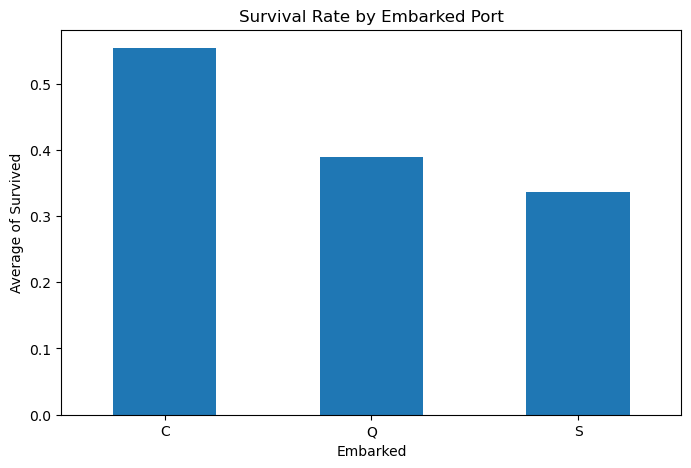

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate average survival rate for each Embarked port
survival_rate = df.groupby('Embarked')['Survived'].mean()

# Create bar chart
plt.figure(figsize=(8, 5))
survival_rate.plot(kind='bar')

plt.title('Survival Rate by Embarked Port')
plt.xlabel('Embarked')
plt.ylabel('Average of Survived')
plt.xticks(rotation=0)

plt.show()

# Cell 2: Highest survival rate identify

In [5]:
highest_port = survival_rate.idxmax()
highest_rate = survival_rate.max()

print("Port with the highest survival rate:", highest_port)
print("Highest survival rate:", round(highest_rate * 100, 2), "%")

Port with the highest survival rate: C
Highest survival rate: 55.36 %


# Q2. Create a new column FamilySize using:
## FamilySize = SibSp + Parch + 1
## Then create a Count Plot showing the number of passengers for each family-size category.
## X-axis: FamilySize
## Y-axis: Number of Passengers
## Identify the most common family size.

## Survival Rate by Embarked Port

# Cell 1: Calculate survival rate

In [6]:
survival_rate = df.groupby('Embarked')['Survived'].mean()

print(survival_rate)

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


# Cell 3:  Create the bar chart

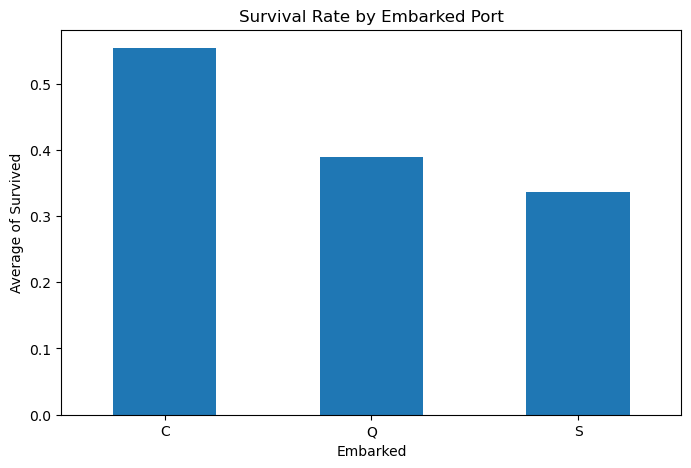

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

survival_rate.plot(kind='bar')

plt.title('Survival Rate by Embarked Port')
plt.xlabel('Embarked')
plt.ylabel('Average of Survived')
plt.xticks(rotation=0)

plt.show()

## Cell 3: Find the port with the highest survival rate

In [8]:
highest_port = survival_rate.idxmax()
highest_rate = survival_rate.max()

print("Port with the highest survival rate:", highest_port)
print("Highest survival rate:", round(highest_rate * 100, 2), "%")

Port with the highest survival rate: C
Highest survival rate: 55.36 %


# Family Size

## Cell 4:Create the FamilySize column

In [9]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


## Cell 5: Create the Count Plot

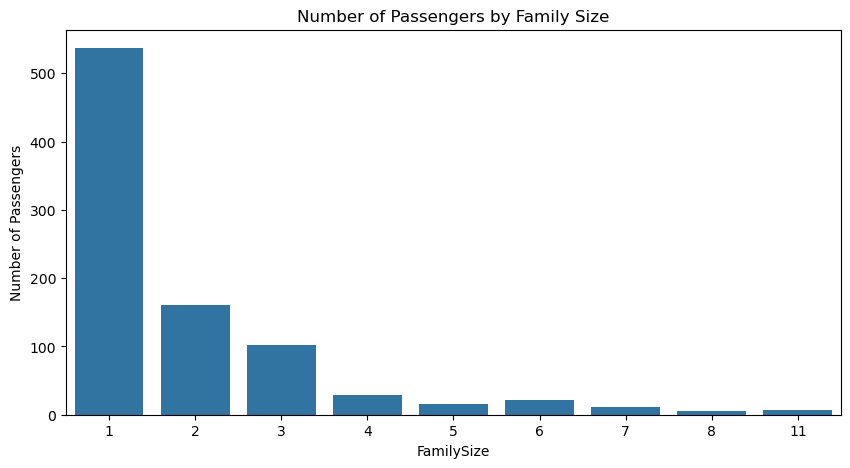

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

sns.countplot(data=df, x='FamilySize')

plt.title('Number of Passengers by Family Size')
plt.xlabel('FamilySize')
plt.ylabel('Number of Passengers')

plt.show()

## Cell 6: Find the most common family size

In [11]:
family_size_counts = df['FamilySize'].value_counts()

most_common_family_size = family_size_counts.idxmax()
most_common_count = family_size_counts.max()

print("Most common family size:", most_common_family_size)
print("Number of passengers:", most_common_count)

Most common family size: 1
Number of passengers: 537


# Q3. Fare Across Pclass and Sex

## Cell 7: Import libraries

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

## Cell 8: Create the Box Plot

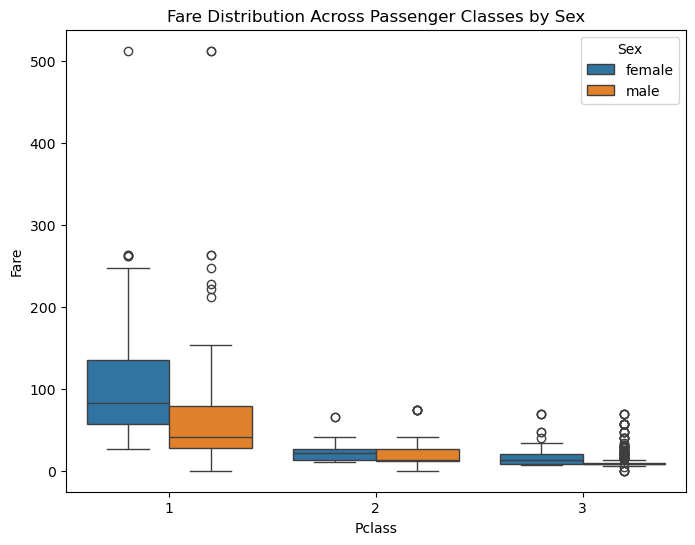

In [13]:
plt.figure(figsize=(8, 6))

sns.boxplot(data=df, x='Pclass', y='Fare', hue='Sex')

plt.title('Fare Distribution Across Passenger Classes by Sex')
plt.xlabel('Pclass')
plt.ylabel('Fare')

plt.show()

## Cell 9: Identify the group with the highest fare

In [14]:
highest_fare = df.loc[df['Fare'].idxmax()]

print("Passenger class:", highest_fare['Pclass'])
print("Sex:", highest_fare['Sex'])
print("Highest fare:", highest_fare['Fare'])

Passenger class: 1
Sex: female
Highest fare: 512.3292


# Q4. Family Size and Survival Rate

In [ ]:
### Already created FamilySize in Q2

## Cell 10: Calculate average survival rate for each family size

In [17]:
family_survival_rate = df.groupby('FamilySize')['Survived'].mean()

print(family_survival_rate)

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64


## Cell 11: Create the Line Plot

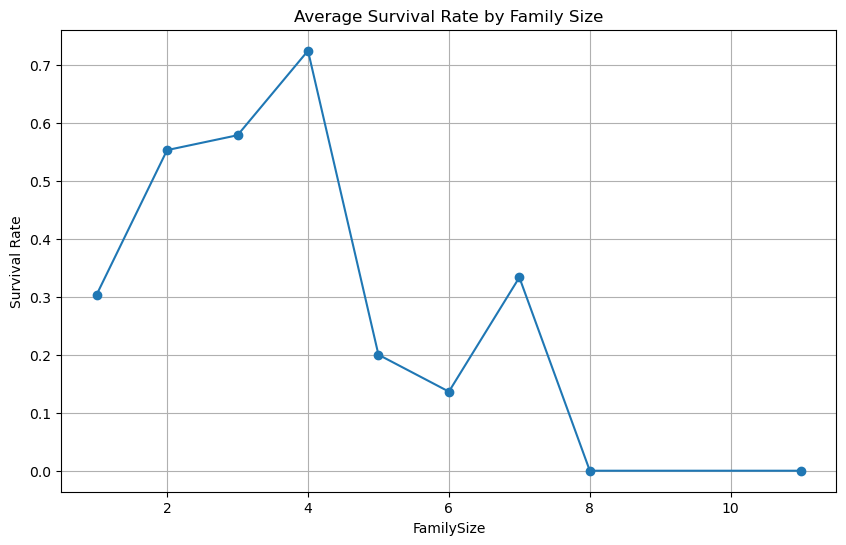

In [18]:
plt.figure(figsize=(10, 6))

plt.plot(
    family_survival_rate.index,
    family_survival_rate.values,
    marker='o'
)

plt.title('Average Survival Rate by Family Size')
plt.xlabel('FamilySize')
plt.ylabel('Survival Rate')

plt.grid(True)
plt.show()

## Cell 12: Identify the family size with the highest survival rate

In [19]:
highest_survival_family = family_survival_rate.idxmax()
highest_survival_rate = family_survival_rate.max()

print("Family size with the highest survival rate:", highest_survival_family)
print("Highest survival rate:", round(highest_survival_rate * 100, 2), "%")

Family size with the highest survival rate: 4
Highest survival rate: 72.41 %


### Note: Q4

### Family size 4 had the highest survival rate, approximately 72.41%.

# Q5.Passenger Class & Gender Survival Comparison¶
# Create a stacked bar chart showing the number of Survived and Not Survived passengers for each combination of Pclass and Sex.

## Cell 13: Create the survival count table

In [20]:
survival_counts = pd.crosstab(
    [df['Pclass'], df['Sex']],
    df['Survived']
)

survival_counts.columns = ['Not Survived', 'Survived']

print(survival_counts)

               Not Survived  Survived
Pclass Sex                           
1      female             3        91
       male              77        45
2      female             6        70
       male              91        17
3      female            72        72
       male             300        47


### Cell 14: Create the Stacked Bar Chart

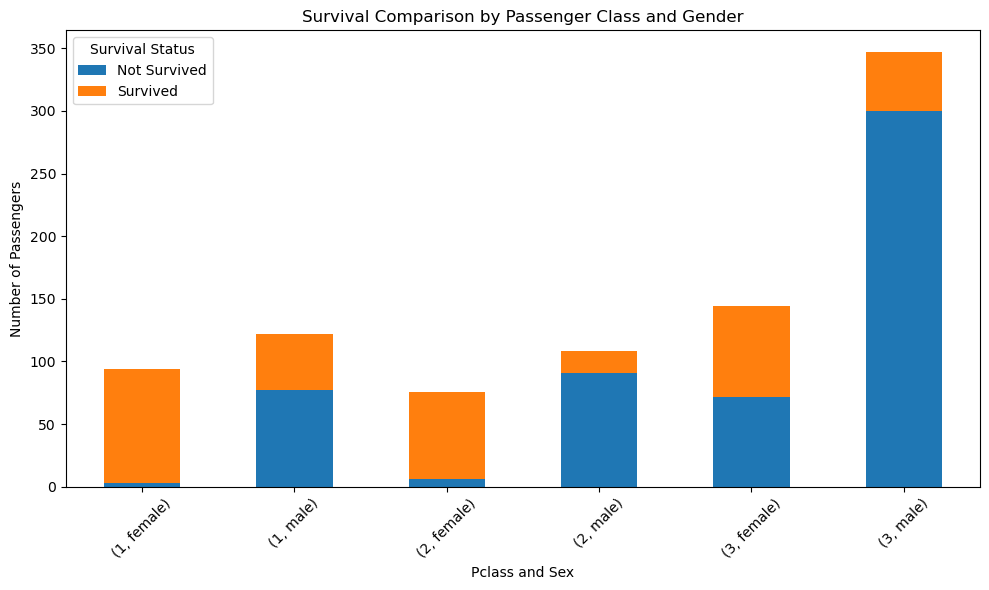

In [21]:
survival_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Survival Comparison by Passenger Class and Gender')
plt.xlabel('Pclass and Sex')
plt.ylabel('Number of Passengers')

plt.xticks(rotation=45)

plt.legend(title='Survival Status')

plt.tight_layout()
plt.show()

### Cell 15: Identify the survival counts

In [22]:
print("Survival counts by Pclass and Sex:")
print(survival_counts)

Survival counts by Pclass and Sex:
               Not Survived  Survived
Pclass Sex                           
1      female             3        91
       male              77        45
2      female             6        70
       male              91        17
3      female            72        72
       male             300        47
